# dp-CO$_2$ metrics benchmark notebook

This notebook unifies the **dp-CO$_2$ approach** metric analysis for three metric families:

- `gwp` → dpGWP point values (`gwp_pointvalue{gas}_{MY}`)
- `rf` → instantaneous radiative forcing (`rf_pointvalue{gas}_{MY}`)
- `agwp` → cumulative radiative forcing (`agwp_pointvalue{gas}_{MY}`)

It follows the same logic as the new fixed-CO$_2$ notebook:

1. load Module B (using IPCC analytical impulse response function) calculated metrics from `metrics_2026-02-23`
2. load Module C (using new prospective decay function) calculated metrics from `metrics_AGWP_wh_ModC_CC_T`
3. build harmonized dataframes
4. export Excel / NetCDF
5. benchmark Module B vs Module C with shared functions
6. switch metric family with **one config variable** instead of maintaining separate notebooks


In [1]:
import os
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.rcParams['font.family'] = 'Times New Roman'
matplotlib.style.use('tableau-colorblind10')

## configuration

In [2]:
# ---- choose metric family  ----
METRIC_KIND = "agwp"   # options: "gwp", "rf", "agwp"

EXPORT_OUTPUTS = False

In [3]:

# horizon setup
len_cf = 101
HORIZON_YEARS = np.arange(len_cf)

# scenarios and model years
ssps = ["119", "245", "585"]
MYs = [2030, 2040, 2050]
ghggass = ["CO2", "CH4", "N2O"]

# metric directories
metric_dir_modB = "../FaIR_dpCFs/output/metrics_2026-02-23/"
metric_dir_modC = "../FaIR_dpCFs/output/metrics_AGWP_wh_ModC_CC_T/"

# workbook naming template
filename_template_modB = "agwp_dcf_gwp100_tstep1{gas}_ssp{ssp}_fair_start1750MY{MY}.xlsx"
filename_template_modC = "agwp_by_pIRF_tstep1{gas}_ssp{ssp}_fair_start1750MY{MY}.xlsx"

# plotting style
ssp_labels = {"119": "SSP1-1.9", "245": "SSP2-4.5", "585": "SSP5-8.5"}
ssp_colors = {"119": "#43dde6", "245": "#364f6b", "585": "#fc5185"}

In [4]:

def get_metric_meta(metric_kind: str):
    metric_kind = metric_kind.lower()

    if metric_kind == "gwp":
        return {
            "sheet_template": "gwp_pointvalue{gas}_{MY}",
            "suffix": "GWP",
            "value_label": "dpGWP",
            "panel_ylabel": "dpGWP (dp-CO$_2$)",
            "suptitle": "Benchmark of dp-CO$_2$ dpGWP metrics: with IPCC analytical IRF (dashed lines) vs prospective decay (solid lines)",
            "export_stub": "dpGWP_dpCO2",
            "nc_stub": "GWP",
        }
    elif metric_kind == "rf":
        return {
            "sheet_template": "rf_pointvalue{gas}_{MY}",
            "suffix": "RF",
            "value_label": "instantaneous RF",
            "panel_ylabel": "Instantaneous RF",
            "suptitle": "Benchmark of dp-CO$_2$ instantaneous RF metrics: with IPCC analytical IRF (dashed lines) vs prospective decay (solid lines)",
            "export_stub": "dRF_dpCO2",
            "nc_stub": "RF",
        }
    elif metric_kind == "agwp":
        return {
            "sheet_template": "agwp_pointvalue{gas}_{MY}",
            "suffix": "AGWP",
            "value_label": "cumulative RF",
            "panel_ylabel": "Cumulative RF",
            "suptitle": "Benchmark of dp-CO$_2$ cumulative RF metrics: with IPCC analytical IRF (dashed lines) vs prospective decay (solid lines)",
            "export_stub": "dCRF_dpCO2",
            "nc_stub": "CRF",
        }
    else:
        raise ValueError("METRIC_KIND must be one of: 'gwp', 'rf', 'agwp'")





In [5]:
META = get_metric_meta(METRIC_KIND)
META

{'sheet_template': 'agwp_pointvalue{gas}_{MY}',
 'suffix': 'AGWP',
 'value_label': 'cumulative RF',
 'panel_ylabel': 'Cumulative RF',
 'suptitle': 'Benchmark of dp-CO$_2$ cumulative RF metrics: with IPCC analytical IRF (dashed lines) vs prospective decay (solid lines)',
 'export_stub': 'dCRF_dpCO2',
 'nc_stub': 'CRF'}

## helper functions

In [6]:
def load_metric_pointvalue_dict(metric_dir, filename_template, ghg_list, ssps, MYs, sheet_template):
    """
    Read metric point-value vectors from metric workbooks.
    Output:
        out[gas][ssp][MY] -> np.ndarray
    """
    metric_dir = Path(metric_dir)
    out = defaultdict(lambda: defaultdict(dict))

    for gas in ghg_list:
        for sp in ssps:
            for MY in MYs:
                filename = filename_template.format(gas=gas, ssp=sp, MY=MY)
                cf_file = metric_dir / filename
                sheet_name = sheet_template.format(gas=gas, MY=MY)

                cf_df = pd.read_excel(cf_file, sheet_name=sheet_name)
                out[gas][f"ssp{sp}"][str(MY)] = pd.to_numeric(cf_df[gas], errors="coerce").to_numpy()

    return out


def build_metric_dataframe(metric_results, metric_suffix, strip_ssp_prefix=False, integer_dims=False):
    records = []

    ref_gas = list(metric_results.keys())[0]
    for ssp in metric_results[ref_gas].keys():
        for my in metric_results[ref_gas][ssp].keys():
            arr_len = len(metric_results[ref_gas][ssp][my])

            for year in range(arr_len):
                row = {
                    "SSP": ssp,
                    "ModelYear": my,
                    "Year": year,
                }
                for gas in metric_results.keys():
                    row[f"{gas}_{metric_suffix}"] = metric_results[gas][ssp][my][year]
                records.append(row)

    df_out = pd.DataFrame(records)

    if strip_ssp_prefix:
        df_out["SSP"] = df_out["SSP"].astype(str).str.replace("ssp", "", regex=False)

    if integer_dims:
        df_out["ModelYear"] = pd.to_numeric(df_out["ModelYear"], errors="coerce").astype(int)
        df_out["Year"] = pd.to_numeric(df_out["Year"], errors="coerce").astype(int)

    return df_out.set_index(["SSP", "ModelYear", "Year"]).sort_index()


def export_metric_outputs(df_formatted, out_dir, excel_name, nc_name_full, nc_name_hpos):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    df_formatted.to_excel(out_dir / excel_name, index=True)

    xr_full = df_formatted.to_xarray()
    xr_full.to_netcdf(out_dir / nc_name_full)

    df_hpos = df_formatted[~(df_formatted.index.get_level_values("Year") == 0)].copy()
    xr_hpos = df_hpos.to_xarray()
    xr_hpos.to_netcdf(out_dir / nc_name_hpos)

    return df_hpos, xr_full, xr_hpos


def plot_single_metric_panels(df_metric, metric_suffix, gas_order=None, my_order=None, ylabel=None):
    gas_order = gas_order or ["CO2", "CH4", "N2O"]
    my_order = my_order or [2030, 2040, 2050]

    fig, axes = plt.subplots(3, 3, figsize=(15, 11), sharex=False, sharey=False)

    for r, gas in enumerate(gas_order):
        for c, my in enumerate(my_order):
            ax = axes[r, c]
            sub = df_metric.reset_index()
            sub = sub[(sub["Gas"] == gas) & (sub["ModelYear"] == my)].copy()

            for ssp in ["119", "245", "585"]:
                s = sub[sub["SSP"] == ssp].sort_values("Year")
                if s.empty:
                    continue
                ax.plot(s["Year"], s["value"], color=ssp_colors[ssp], linewidth=1.8)

            ax.set_title(f"{gas}, MY={my}", fontsize=11)
            ax.set_xlabel("Time after emission")
            if c == 0:
                ax.set_ylabel(ylabel)
            ax.grid(False)

    ssp_handles = [
        Line2D([0], [0], color=ssp_colors[k], lw=2, label=ssp_labels[k])
        for k in ["119", "245", "585"]
    ]

    fig.legend(
        handles=ssp_handles,
        loc="upper center",
        fontsize=13,
        bbox_to_anchor=(0.5, 0.94),
        ncol=3,
        frameon=True,
        title="Scenario"
    )

    fig.subplots_adjust(top=0.88, bottom=0.07, left=0.08, right=0.98, hspace=0.42, wspace=0.25)
    plt.show()


def wide_to_long_for_benchmark(df_wide, metric_suffix, value_label, approach_name):
    value_cols = [f"CO2_{metric_suffix}", f"CH4_{metric_suffix}", f"N2O_{metric_suffix}"]

    long_df = (
        df_wide
        .reset_index()
        .melt(
            id_vars=["SSP", "ModelYear", "Year"],
            value_vars=value_cols,
            var_name="Gas",
            value_name=value_label,
        )
    )
    long_df["Gas"] = long_df["Gas"].str.replace(f"_{metric_suffix}", "", regex=False)
    long_df["Approach"] = approach_name
    return long_df


def standardize_benchmark_keys(df_long):
    df_long = df_long.copy()
    df_long["SSP"] = df_long["SSP"].astype(str).str.strip().str.replace("ssp", "", regex=False)
    df_long["Gas"] = df_long["Gas"].astype(str).str.strip()
    df_long["ModelYear"] = pd.to_numeric(df_long["ModelYear"], errors="coerce").astype("Int64")
    df_long["Year"] = pd.to_numeric(df_long["Year"], errors="coerce").astype("Int64")
    return df_long


def build_benchmark_dataframe(df_modB, df_modC, metric_suffix, value_label):
    long_modB = standardize_benchmark_keys(
        wide_to_long_for_benchmark(df_modB, metric_suffix=metric_suffix, value_label=value_label, approach_name="Module B")
    )
    long_modC = standardize_benchmark_keys(
        wide_to_long_for_benchmark(df_modC, metric_suffix=metric_suffix, value_label=value_label, approach_name="Module C")
    )

    bench = (
        long_modB
        .merge(
            long_modC,
            on=["SSP", "ModelYear", "Year", "Gas"],
            suffixes=("_ModB", "_ModC"),
            how="inner",
            validate="one_to_one",
        )
        .drop(columns=["Approach_ModB", "Approach_ModC"])
    )

    bench["abs_diff"] = bench[f"{value_label}_ModC"] - bench[f"{value_label}_ModB"]
    bench["abs_diff_abs"] = bench["abs_diff"].abs()
    bench["pct_diff_vs_ModB"] = np.where(
        bench[f"{value_label}_ModB"] != 0,
        100 * bench["abs_diff"] / bench[f"{value_label}_ModB"],
        np.nan,
    )
    bench["pct_diff_abs"] = bench["pct_diff_vs_ModB"].abs()
    return bench


def summarize_benchmark(benchmark_df, value_label):
    summary_stats = (
        benchmark_df[benchmark_df["Year"] > 0]
        .groupby(["Gas", "SSP", "ModelYear"], as_index=False)
        .agg(
            mean_ModB=(f"{value_label}_ModB", "mean"),
            mean_ModC=(f"{value_label}_ModC", "mean"),
            mean_abs_diff=("abs_diff", "mean"),
            mean_abs_diff_abs=("abs_diff_abs", "mean"),
            max_abs_diff_abs=("abs_diff_abs", "max"),
            mean_pct_diff=("pct_diff_vs_ModB", "mean"),
            max_pct_diff_abs=("pct_diff_abs", "max"),
        )
    )

    for H in [20, 50, 100]:
        tmp = benchmark_df[benchmark_df["Year"] == H][["Gas", "SSP", "ModelYear", f"{value_label}_ModB", f"{value_label}_ModC", "abs_diff", "pct_diff_vs_ModB"]].copy()
        tmp = tmp.rename(columns={
            f"{value_label}_ModB": f"ModB_H{H}",
            f"{value_label}_ModC": f"ModC_H{H}",
            "abs_diff": f"abs_diff_H{H}",
            "pct_diff_vs_ModB": f"pct_diff_H{H}",
        })
        summary_stats = summary_stats.merge(tmp, on=["Gas", "SSP", "ModelYear"], how="left")

    summary_stats = summary_stats.sort_values(["Gas", "ModelYear", "SSP"]).reset_index(drop=True)

    summary_by_gas = (
        benchmark_df[benchmark_df["Year"] > 0]
        .groupby("Gas", as_index=False)
        .agg(
            mean_ModB=(f"{value_label}_ModB", "mean"),
            mean_ModC=(f"{value_label}_ModC", "mean"),
            mean_abs_diff=("abs_diff", "mean"),
            max_abs_diff_abs=("abs_diff_abs", "max"),
            mean_pct_diff=("pct_diff_vs_ModB", "mean"),
            max_pct_diff_abs=("pct_diff_abs", "max"),
        )
    )

    return summary_stats, summary_by_gas


def plot_benchmark_3x3(benchmark_df, value_label, panel_ylabel, suptitle, gas_order=None, my_order=None):
    gas_order = gas_order or ["CO2", "CH4", "N2O"]
    my_order = my_order or [2030, 2040, 2050]

    fig, axes = plt.subplots(3, 3, figsize=(15, 11), sharex=False, sharey=False)

    for r, gas in enumerate(gas_order):
        for c, my in enumerate(my_order):
            ax = axes[r, c]
            sub = benchmark_df[
                (benchmark_df["Gas"] == gas) &
                (benchmark_df["ModelYear"] == my) &
                (benchmark_df["Year"] > 0)
            ].copy()

            for ssp in ["119", "245", "585"]:
                s = sub[sub["SSP"] == ssp].sort_values("Year")
                if s.empty:
                    continue

                color = ssp_colors[ssp]

                ax.plot(
                    s["Year"], s[f"{value_label}_ModB"],
                    linestyle="--",
                    color=color,
                    linewidth=1.8
                )
                ax.plot(
                    s["Year"], s[f"{value_label}_ModC"],
                    linestyle="-",
                    color=color,
                    linewidth=1.8
                )

            ax.set_title(f"{gas}, MY={my}", fontsize=12)
            ax.set_xlabel("Time after emission")
            if c == 0:
                ax.set_ylabel(panel_ylabel)
            ax.grid(False)

    ssp_handles = [
        Line2D([0], [0], color=ssp_colors[k], lw=2, label=ssp_labels[k])
        for k in ["119", "245", "585"]
    ]
    method_handles = [
        Line2D([0], [0], color="black", lw=2, linestyle="--", label="IPCC analytical IRF"),
        Line2D([0], [0], color="black", lw=2, linestyle="-", label="prospective decay"),
    ]

    fig.legend(
        handles=ssp_handles,
        loc="upper center",
        fontsize=13,
        bbox_to_anchor=(0.36, 0.95),
        ncol=3,
        frameon=True,
        title="Scenario"
    )

    fig.legend(
        handles=method_handles,
        loc="upper center",
        fontsize=13,
        bbox_to_anchor=(0.72, 0.95),
        ncol=2,
        frameon=True,
        title="Metric calculation"
    )

    fig.suptitle(suptitle, fontsize=15)
    fig.subplots_adjust(top=0.86, bottom=0.07, left=0.08, right=0.98, hspace=0.42, wspace=0.25)
    plt.show()


## A. using Module B: load dp-CO$_2$ metric family from FaIR Folder `metrics_2026-02-23`

In [7]:

metric_results_modB = load_metric_pointvalue_dict(
    metric_dir=metric_dir_modB,
    filename_template=filename_template_modB,
    ghg_list=ghggass,
    ssps=ssps,
    MYs=MYs,
    sheet_template=META["sheet_template"],
)

# quick spot checks
metric_results_modB["CO2"]["ssp119"]["2030"][:5], metric_results_modB["CH4"]["ssp119"]["2030"][:5]


(array([0.00000000e+00, 1.56126662e-15, 3.02686213e-15, 4.41424256e-15,
        5.73730450e-15]),
 array([0.00000000e+00, 2.12380718e-13, 4.06260670e-13, 5.83405462e-13,
        7.45335004e-13]))

In [8]:

df_modB = build_metric_dataframe(
    metric_results=metric_results_modB,
    metric_suffix=META["suffix"],
    strip_ssp_prefix=True,
    integer_dims=True,
)

if EXPORT_OUTPUTS:
    _, xr_modB_full, xr_modB_hpos = export_metric_outputs(
        df_formatted=df_modB,
        out_dir=f"output_{META['export_stub']}_modB",
        excel_name=f"{META['export_stub']}_CO2CH4N2O_modB.xlsx",
        nc_name_full=f"CF_{META['nc_stub']}0_100_perSSP_MY_majorghgs_ModB.nc",
        nc_name_hpos=f"CF_{META['nc_stub']}1_100_perSSP_MY_majorghgs_ModB.nc",
    )

print(df_modB.shape)
df_modB.head()


(909, 3)


CO2_AGWP      CH4_AGWP      N2O_AGWP
SSP ModelYear Year                                          
119 2030      0     0.000000e+00  0.000000e+00  0.000000e+00
              1     1.561267e-15  2.123807e-13  2.822272e-13
              2     3.026862e-15  4.062607e-13  5.619003e-13
              3     4.414243e-15  5.834055e-13  8.392651e-13
              4     5.737304e-15  7.453350e-13  1.114251e-12

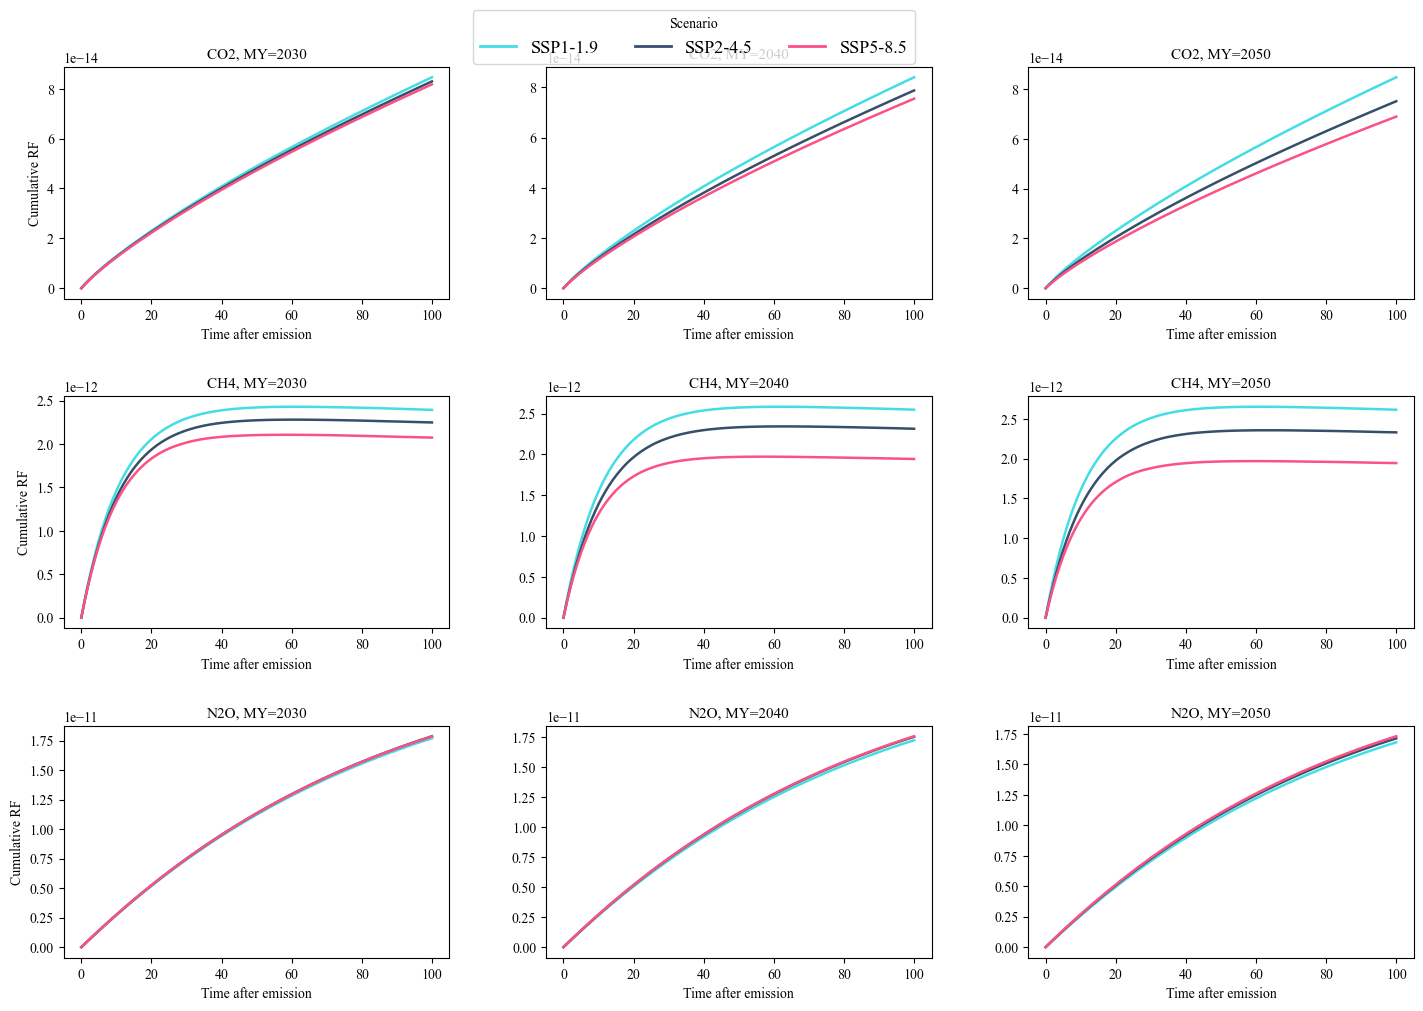

In [9]:

long_modB_preview = wide_to_long_for_benchmark(
    df_modB, metric_suffix=META["suffix"], value_label="value", approach_name="Module B"
)
plot_single_metric_panels(
    df_metric=long_modB_preview,
    metric_suffix=META["suffix"],
    ylabel=META["panel_ylabel"],
)


## B. Module C: load dp-CO$_2$ metric family from FaIR folder:  `metrics_AGWP_wh_ModC_CC_T`

In [10]:

metric_results_modC = load_metric_pointvalue_dict(
    metric_dir=metric_dir_modC,
    filename_template=filename_template_modC,
    ghg_list=ghggass,
    ssps=ssps,
    MYs=MYs,
    sheet_template=META["sheet_template"],
)

metric_results_modC["CO2"]["ssp119"]["2030"][:5], metric_results_modC["CH4"]["ssp119"]["2030"][:5]


(array([0.00000000e+00, 1.55489084e-15, 3.00654236e-15, 4.38917558e-15,
        5.71493928e-15]),
 array([0.00000000e+00, 2.13754886e-13, 4.11020961e-13, 5.92965196e-13,
        7.60539998e-13]))

In [11]:

df_modC = build_metric_dataframe(
    metric_results=metric_results_modC,
    metric_suffix=META["suffix"],
    strip_ssp_prefix=True,
    integer_dims=True,
)

if EXPORT_OUTPUTS:
    _, xr_modC_full, xr_modC_hpos = export_metric_outputs(
        df_formatted=df_modC,
        out_dir=f"output_{META['export_stub']}_modC",
        excel_name=f"{META['export_stub']}_CO2CH4N2O_modC.xlsx",
        nc_name_full=f"CF_{META['nc_stub']}0_100_perSSP_MY_majorghgs_ModC.nc",
        nc_name_hpos=f"CF_{META['nc_stub']}1_100_perSSP_MY_majorghgs_ModC.nc",
    )

print(df_modC.shape)
df_modC.head()


(1809, 3)


CO2_AGWP      CH4_AGWP      N2O_AGWP
SSP ModelYear Year                                          
119 2030      0     0.000000e+00  0.000000e+00  0.000000e+00
              1     1.554891e-15  2.137549e-13  2.820203e-13
              2     3.006542e-15  4.110210e-13  5.606687e-13
              3     4.389176e-15  5.929652e-13  8.359816e-13
              4     5.714939e-15  7.605400e-13  1.107995e-12

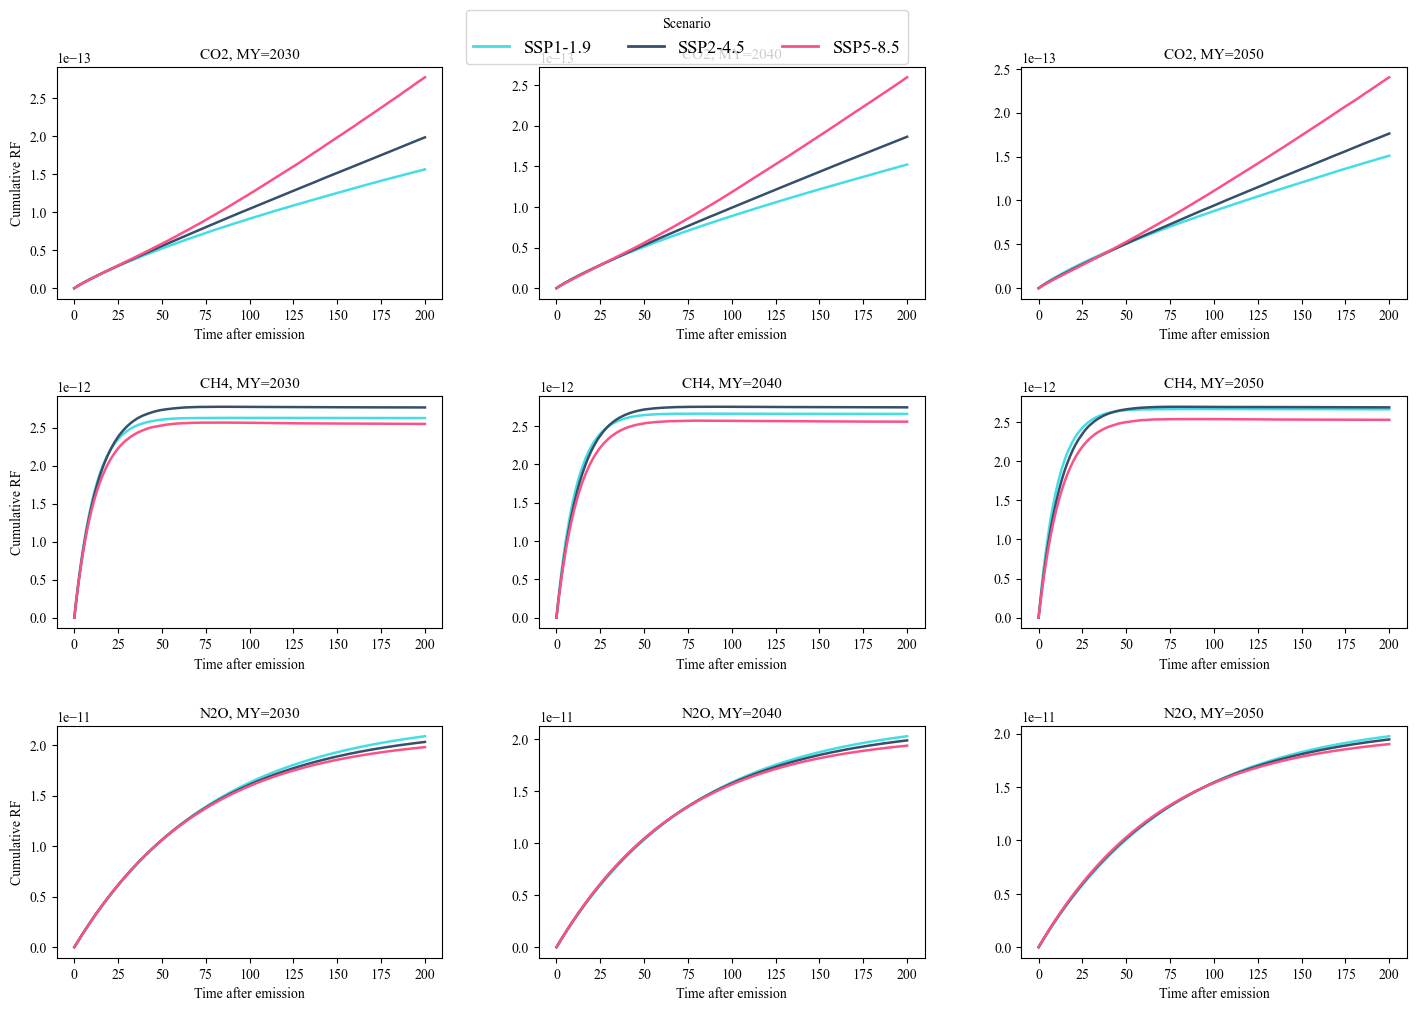

In [12]:

long_modC_preview = wide_to_long_for_benchmark(
    df_modC, metric_suffix=META["suffix"], value_label="value", approach_name="Module C"
)
plot_single_metric_panels(
    df_metric=long_modC_preview,
    metric_suffix=META["suffix"],
    ylabel=META["panel_ylabel"],
)


## C. Benchmark Module B vs Module C

In [13]:

benchmark_df = build_benchmark_dataframe(
    df_modB=df_modB,
    df_modC=df_modC,
    metric_suffix=META["suffix"],
    value_label=META["value_label"],
)

print("benchmark_df shape:", benchmark_df.shape)
display(benchmark_df.head(12))


benchmark_df shape: (2727, 10)


,SSP,ModelYear,Year,Gas,cumulative RF_ModB,cumulative RF_ModC,abs_diff,abs_diff_abs,pct_diff_vs_ModB,pct_diff_abs
0,119,2030,0,CO2,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,NaN,NaN
1,119,2030,1,CO2,1.561267e-15,1.554891e-15,-6.375781e-18,6.375781e-18,-0.408372,0.408372
2,119,2030,2,CO2,3.026862e-15,3.006542e-15,-2.031977e-17,2.031977e-17,-0.671315,0.671315
3,119,2030,3,CO2,4.414243e-15,4.389176e-15,-2.506698e-17,2.506698e-17,-0.567866,0.567866
4,119,2030,4,CO2,5.737304e-15,5.714939e-15,-2.236522e-17,2.236522e-17,-0.389821,0.389821
5,119,2030,5,CO2,7.007121e-15,7.004146e-15,-2.975559e-18,2.975559e-18,-0.042465,0.042465
6,119,2030,6,CO2,8.232528e-15,8.262813e-15,3.028522e-17,3.028522e-17,0.367873,0.367873
7,119,2030,7,CO2,9.420581e-15,9.491489e-15,7.090838e-17,7.090838e-17,0.752697,0.752697
8,119,2030,8,CO2,1.057693e-14,1.069879e-14,1.218580e-16,1.218580e-16,1.152112,1.152112
9,119,2030,9,CO2,1.170610e-14,1.188211e-14,1.760052e-16,1.760052e-16,1.503534,1.503534


In [14]:

summary_stats, summary_by_gas = summarize_benchmark(
    benchmark_df=benchmark_df,
    value_label=META["value_label"],
)

display(summary_stats)
display(summary_by_gas)


,Gas,SSP,ModelYear,mean_ModB,mean_ModC,mean_abs_diff,mean_abs_diff_abs,max_abs_diff_abs,mean_pct_diff,max_pct_diff_abs,...,abs_diff_H20,pct_diff_H20,ModB_H50,ModC_H50,abs_diff_H50,pct_diff_H50,ModB_H100,ModC_H100,abs_diff_H100,pct_diff_H100
0,CH4,119,2030,2.180497e-12,2.346936e-12,1.664382e-13,1.664382e-13,2.348369e-13,7.227831,9.808673,...,1.257022e-13,6.112249,2.421664e-12,2.606903e-12,1.852385e-13,7.649221,2.394176e-12,2.629013e-12,2.348369e-13,9.808673
1,CH4,245,2030,2.049409e-12,2.436595e-12,3.871858e-13,3.871858e-13,5.248678e-13,17.695561,23.339348,...,2.463997e-13,12.724486,2.274127e-12,2.734410e-12,4.602831e-13,20.239992,2.248854e-12,2.773722e-12,5.248678e-13,23.339348
2,CH4,585,2030,1.907192e-12,2.267589e-12,3.603963e-13,3.603963e-13,4.899794e-13,17.750606,23.620056,...,2.243214e-13,12.240354,2.103424e-12,2.531001e-12,4.275771e-13,20.327668,2.074421e-12,2.564401e-12,4.899794e-13,23.620056
3,CH4,119,2040,2.315492e-12,2.385151e-12,6.965819e-14,6.965819e-14,1.122421e-13,2.890138,4.406730,...,6.066549e-14,2.785231,2.573039e-12,2.641398e-12,6.835898e-14,2.656740,2.547061e-12,2.659303e-12,1.122421e-13,4.406730
4,CH4,245,2040,2.096683e-12,2.419810e-12,3.231278e-13,3.231278e-13,4.363487e-13,14.455485,18.863071,...,2.150393e-13,10.944167,2.331869e-12,2.714008e-12,3.821389e-13,16.387666,2.313243e-12,2.749592e-12,4.363487e-13,18.863071
5,CH4,585,2040,1.789978e-12,2.262322e-12,4.723432e-13,4.723432e-13,6.237237e-13,24.823130,32.095536,...,3.100449e-13,17.918601,1.969002e-12,2.533152e-12,5.641494e-13,28.651536,1.943335e-12,2.567058e-12,6.237237e-13,32.095536
6,CH4,119,2050,2.383474e-12,2.399616e-12,1.614111e-14,1.614111e-14,4.816345e-14,0.690116,1.841288,...,1.914588e-14,0.849843,2.644612e-12,2.648799e-12,4.187084e-15,0.158325,2.615748e-12,2.663911e-12,4.816345e-14,1.841288
7,CH4,245,2050,2.109689e-12,2.379420e-12,2.697310e-13,2.697310e-13,3.607687e-13,12.028010,15.478696,...,1.881592e-13,9.523567,2.346281e-12,2.660641e-12,3.143596e-13,13.398206,2.330743e-12,2.691512e-12,3.607687e-13,15.478696
8,CH4,585,2050,1.781327e-12,2.229498e-12,4.481713e-13,4.481713e-13,5.909744e-13,23.667277,30.394163,...,3.017620e-13,17.682095,1.965156e-12,2.496090e-12,5.309332e-13,27.017352,1.944368e-12,2.535342e-12,5.909744e-13,30.394163
9,CO2,119,2030,4.745744e-14,5.071138e-14,3.253942e-15,3.255484e-15,6.640735e-15,5.837909,7.849037,...,1.033307e-15,4.489830,4.890923e-14,5.214678e-14,3.237557e-15,6.619523,8.460573e-14,9.124646e-14,6.640735e-15,7.849037


,Gas,mean_ModB,mean_ModC,mean_abs_diff,max_abs_diff_abs,mean_pct_diff,max_pct_diff_abs
0,CH4,2.068194e-12,2.347437e-12,2.792437e-13,6.237237e-13,13.469795,32.095536
1,CO2,4.465424e-14,5.338737e-14,8.733128e-15,4.277567e-14,16.118089,61.059900
2,N2O,1.039063e-11,9.653246e-12,-7.373817e-13,1.916873e-12,-5.802664,11.072703


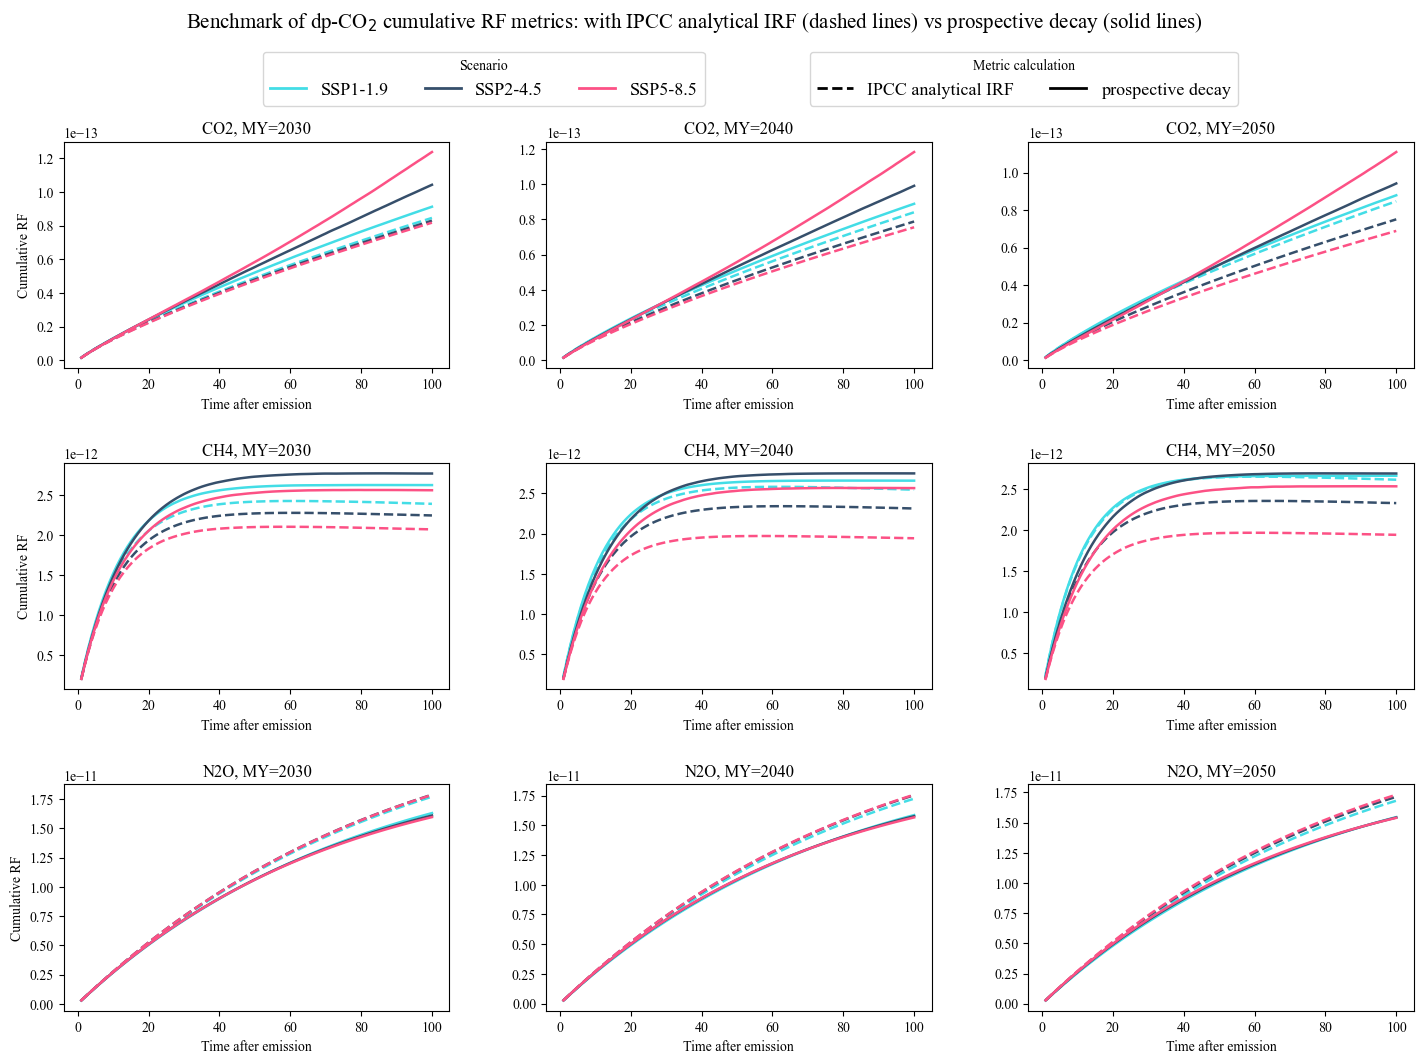

In [15]:

plot_benchmark_3x3(
    benchmark_df=benchmark_df,
    value_label=META["value_label"],
    panel_ylabel=META["panel_ylabel"],
    suptitle=META["suptitle"],
)
